## Imports

In [1]:
import cv2 as cv
import numpy as np
import matplotlib.pyplot as plt

### Constants
- RGB Colors

In [2]:
BLACK = (0, 0, 0)
WHITE = (255, 255, 255)
RED = (255,0,0)
GREEN = (0, 255, 0)
BLUE = (0, 0, 255)
CYAN = (255, 255, 0)
MAGENTA = (255, 0, 255)
YELLOW = (0, 255, 255)

### Blank Canvas
- Create a 600×600 white image using a NumPy array.

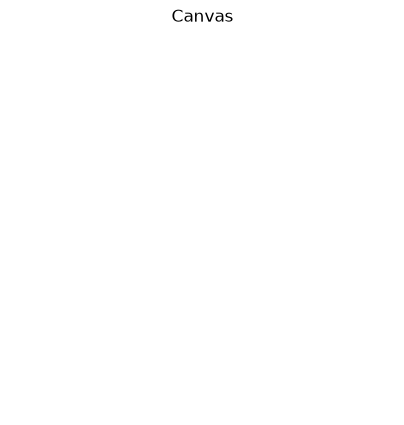

In [3]:
img_rgb = np.full((600, 600, 3), 255, dtype=np.uint8)
# Convert to RGB for "matplotlib"
img_rgb = cv.cvtColor(img_rgb,cv.COLOR_BGR2RGB)
plt.figure(figsize=(5, 5))
plt.imshow(img_rgb)
plt.title("Canvas")
plt.axis("off")
plt.show()
plt.close()

### Red Circle

```python
cv2.circle(image, center, radius, color, thickness)
```

- image: The image on which to draw the circle
- center: (x, y) coordinates of the circle's center.
- radius: Radius of the circle in pixels.
- color: Circle color
- thickness:
    - Positive integer: Draws a outline
    - -1 or cv2.FILLED: Draws a filled circle.


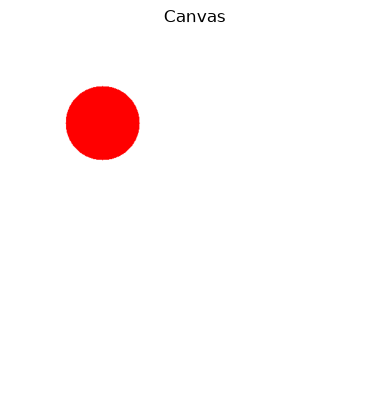

In [ ]:
cv.circle(img_rgb, (150, 150), 60, RED, cv.FILLED)
plt.imshow(img_rgb)
plt.title("Canvas")
plt.axis("off")
plt.show()
plt.close()

### Green Square

```python
cv2.rectangle(image, pt1, pt2, color, thickness)
```

- image: The image on which to draw the rectangle.
- pt1: (x, y) coordinates of the top-left corner.
- pt2: (x, y) coordinates of the bottom-right corner.
- color: Rectangle color.
- thickness:
    - Positive integer: Draws only the outline.
    - -1 or cv2.FILLED: Draws a filled rectangle.

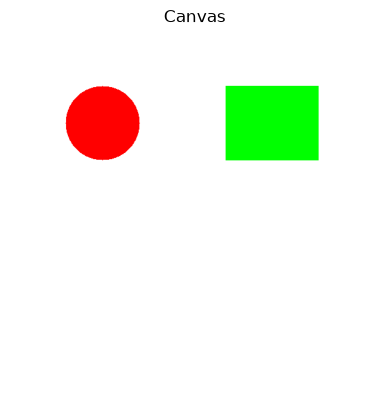

In [5]:
cv.rectangle(img_rgb, (350, 90), (500, 210), GREEN, cv.FILLED)
plt.imshow(img_rgb)
plt.title("Canvas")
plt.axis("off")
plt.show()
plt.close()

### Blue Triangle
This function can be used To construct any polynomial, given its vertices

```python
cv2.fillPoly(image, pts, color)
```

- image: The image on which to draw the polygon.
- pts: NumPy array containing the polygon vertices.
- color: Fill color of the polygon.


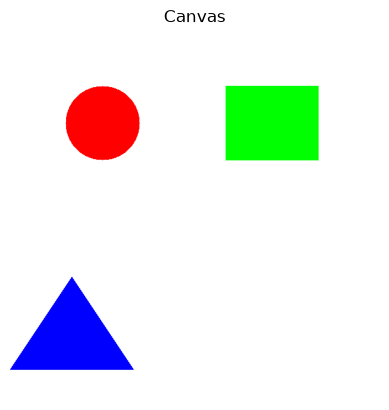

In [6]:
triangle = np.array([[100, 400], [200, 550], [0, 550]], dtype=np.int32)
cv.fillPoly(img_rgb, [triangle], BLUE)
plt.imshow(img_rgb)
plt.title("Canvas")
plt.axis("off")
plt.show()
plt.close()


### Magenta Arrow

```python
cv2.arrowedLine(image, pt1, pt2, color, thickness, line_type, shift, tipLength)
```

- image: The image on which to draw the arrow.
- pt1: Starting point of the arrow.
- pt2: Ending point of the arrow.
- color: Arrow color.
- thickness: Thickness of the arrow line.
- line_type: Type of line (e.g., `cv2.LINE_8`, `cv2.LINE_AA`).
- shift: Number of fractional bits in the point coordinates.
- tipLength: Length of the arrow tip as a fraction of the arrow length.


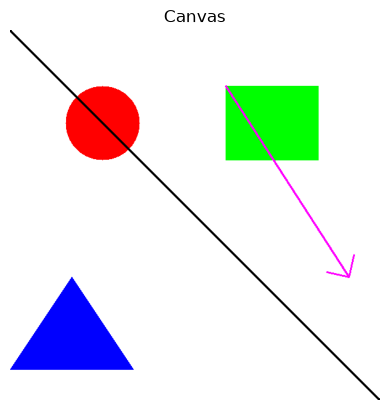

In [13]:
cv.arrowedLine(img_rgb,(350, 90), (550, 400), MAGENTA, 2)
plt.imshow(img_rgb)
plt.title("Canvas")
plt.axis("off")
plt.show()
plt.close()

### Black Diagonal

```python
cv2.line(image, pt1, pt2, color, thickness)
```

- image: The image on which to draw the line.
- pt1: Starting point of the line.
- pt2: Ending point of the line.
- color: Line color.
- thickness: Thickness of the line in pixels.


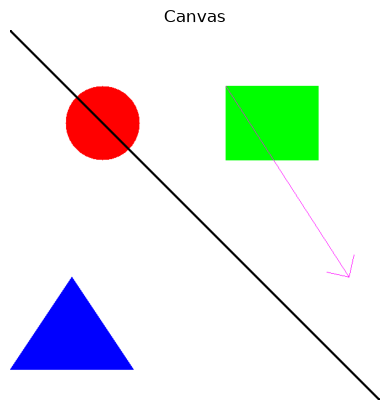

In [8]:
cv.line(img_rgb, (0, 0), (600, 600), BLACK, 2)
plt.imshow(img_rgb)
plt.title("Canvas")
plt.axis("off")
plt.show()
plt.close()

### Save Image

In [9]:
img_bgr = cv.cvtColor(img_rgb, cv.COLOR_RGB2BGR)
cv.imwrite("output/shapes.png", img_bgr)

True

## Convert to HSV, Split the Channels and Visualise

```python
cv2.split(image)
```

Splits a multi-channel image into separate channels.

For an HSV image, the returned channels are:

- **H:** Hue
- **S:** Saturation
- **V:** Value (Brightness)
```

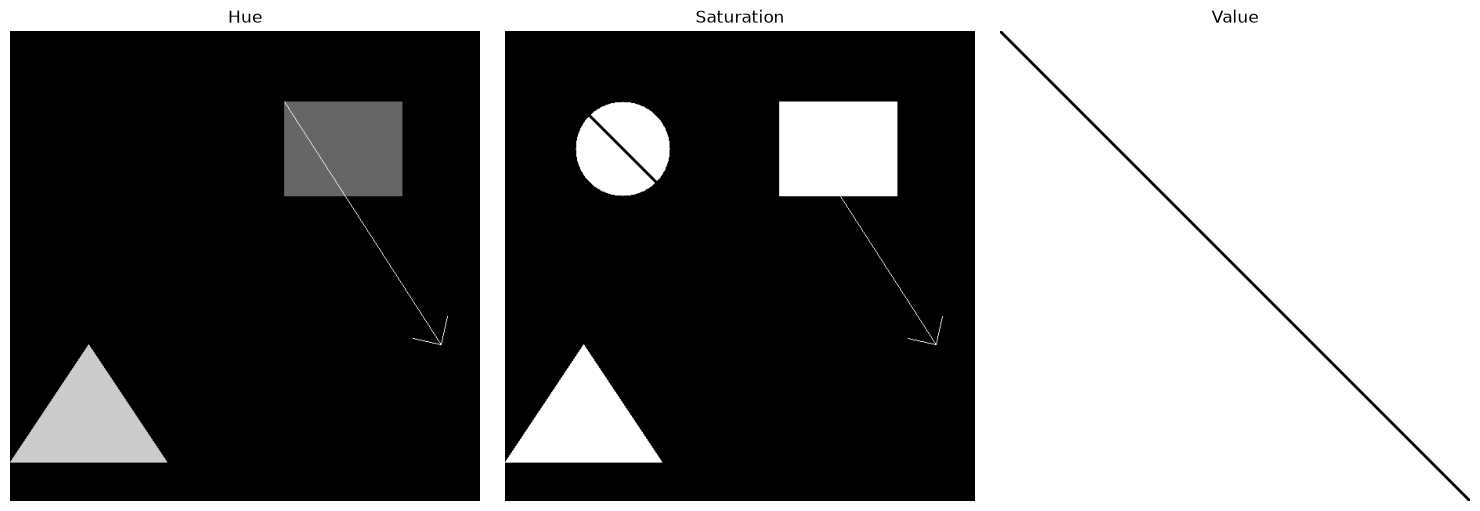

In [10]:
img_hsv = cv.cvtColor(img_bgr, cv.COLOR_BGR2HSV)
H, S, V = cv.split(img_hsv)

plt.figure(figsize=(15,5))

# Subplot for Hue
plt.subplot(1,3,1)
plt.imshow(H, cmap="gray")
plt.title("Hue")
plt.axis("off")

# Subplot for Saturation
plt.subplot(1,3,2)
plt.imshow(S, cmap="gray")
plt.title("Saturation")
plt.axis("off")

# Subplot for Value
plt.subplot(1,3,3)
plt.imshow(V, cmap="gray")
plt.title("Value")
plt.axis("off")

plt.tight_layout()
plt.savefig("output/3_hsv.png")
plt.show()

## HSV Masks

```python
cv2.inRange(src, lowerb, upperb)
```

Creates a binary mask by selecting pixels within a specified HSV range.

- **src:** HSV image.
- **lowerb:** Lower HSV bound.
- **upperb:** Upper HSV bound.
- **Returns:** Binary mask where matching pixels are white (`255`) and all other pixels are black (`0`).
```

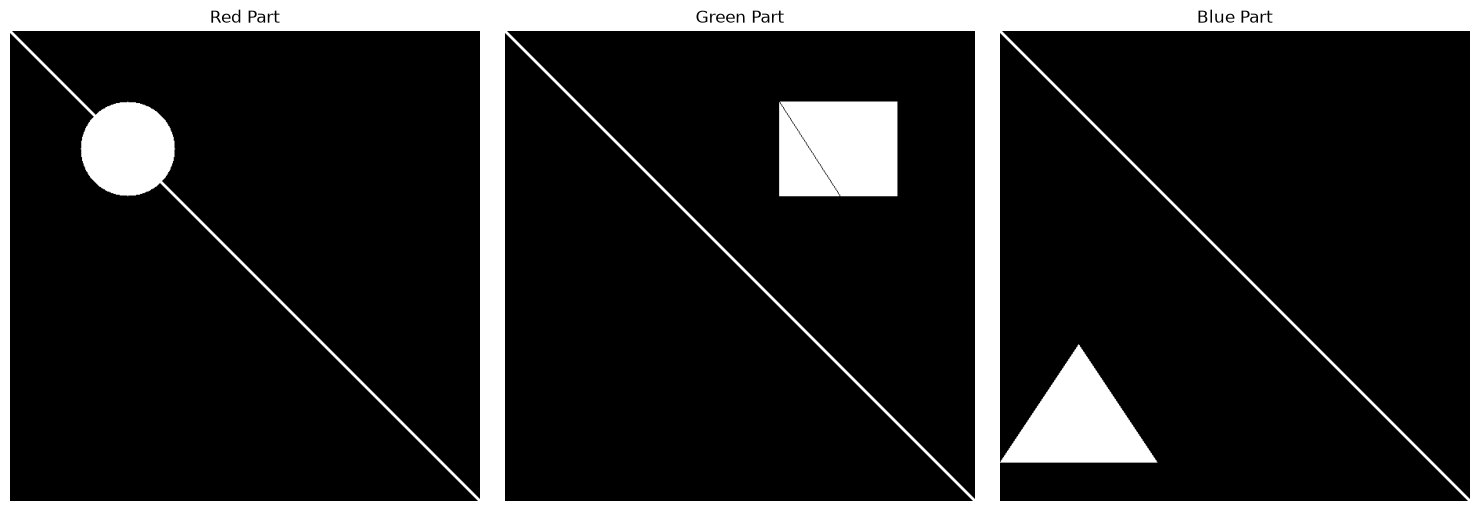

In [11]:
red_img = cv.inRange(img_rgb, BLACK, RED)
green_img = cv.inRange(img_rgb, BLACK, GREEN)
blue_img = cv.inRange(img_rgb, BLACK, BLUE)

plt.figure(figsize=(15,5))

# Subplot for Red Part
plt.subplot(1,3,1)
plt.imshow(red_img, cmap="gray")
plt.title("Red Part")
plt.axis("off")

# Subplot for Green Part
plt.subplot(1,3,2)
plt.imshow(green_img, cmap="gray")
plt.title("Green Part")
plt.axis("off")

# Subplot for Blue Part
plt.subplot(1,3,3)
plt.imshow(blue_img, cmap="gray")
plt.title("Blue Part")
plt.axis("off")

plt.tight_layout()
plt.savefig("output/4_masks.png")
plt.show()

### Numeric Check

```python
cv2.countNonZero(src)
```

- Counts the number of non-zero pixels in each binary mask.

In [12]:
red_pixels = cv.countNonZero(red_img)
green_pixels = cv.countNonZero(green_img)
blue_pixels = cv.countNonZero(blue_img)

print(f"Red Mask Pixels   : {red_pixels}")
print(f"Green Mask Pixels : {green_pixels}")
print(f"Blue Mask Pixels  : {blue_pixels}")

assert 8000 <= red_pixels <= 30000
assert 8000 <= green_pixels <= 30000
assert 8000 <= blue_pixels <= 30000

print("All masks satisfy the required pixel count.")

Red Mask Pixels   : 13860
Green Mask Pixels : 21144
Blue Mask Pixels  : 18245
All masks satisfy the required pixel count.
